<a href="https://colab.research.google.com/github/Azaphz/Peptide-molecule_drug_analisys/blob/main/Peptide-molecule_drug_analisys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependencies

## Pandas

In [1]:
import pandas as pd

## Numpy

In [2]:
import numpy as np

## biopython

### Install Biopython

In [3]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.8 MB/s eta 0:00:00


### Import Biopython

In [4]:
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint

## RDKit

### Install RDKit

In [5]:
!pip install rdkit --quiet

### Import RDKit

#### Draw, Descriptors

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

#### Lipinski

In [7]:
from rdkit.Chem.Lipinski import NumHDonors, NumHAcceptors

## Matplotlib

In [8]:
import matplotlib.pyplot as plt

## MDAnalisys

### Install MDAnalisys

In [9]:
!pip install MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.4 MB/s eta 0:00:00


### Import MDAnalisys

In [10]:
import MDAnalysis as mda

# Script

## **1. Peptide sequence report**
- MV,
- AA composition,
- pI,
- Hydropathy Plot

### AA's Molecular weight pKa

In [11]:
mw = {
    'A': 89.09,  'R': 174.20, 'N': 132.12, 'D': 133.10,
    'C': 121.16, 'E': 147.13, 'Q': 146.15, 'G': 75.03,
    'H': 155.16, 'I': 131.17, 'L': 131.17, 'K': 146.19,
    'M': 149.21, 'F': 165.19, 'P': 115.13, 'S': 105.09,
    'T': 119.12, 'W': 204.23, 'Y': 181.19, 'V': 117.15
}

pKa = {
    'C_term': ["acid", 2.21], 'N_term': ["base", 8.20],
    'D': ["acid", 3.65], 'E': ["acid", 4.25], 'C': ["acid", 8.30], 'Y': ["acid", 10.07],
    'K': ["base", 10.53], 'R': ["base", 12.48], 'H': ["base", 6.00]
}

### Input

In [12]:
def get_seq():
  while True:
    seq = input("Enter a sequence: ").upper().replace(" ","")
    is_valid = True
    for aa in seq:
      if aa not in mw:
        print(f"Invalid character: '{aa}' found. Please enter a valid sequence.")
        is_valid = False
        break
    if is_valid:
      print(f"Sequence is valid\n")
      break

  return seq

###Sequence Length

In [13]:
def get_seq_len(seq):
  seq_len = len(seq)
  return seq_len

### Molecular Weight

In [14]:
def get_mw(seq):
  seq_len = get_seq_len(seq)
  print(f"Length: {seq_len} residues")
  seq_mv = sum(mw[aa] for aa in seq)
  print(f"Raw Molecular Weight: {seq_mv:.2f} Da")
  bonds = seq_len - 1
  true_mv = seq_mv - bonds*18.02
  print(f"True Molecular Weight: {true_mv:.2f} Da (after {bonds} peptide bonds)\n")
  return true_mv

### Amino Acid composition

#### Amino acids count

In [15]:
def get_aa_count(seq):
  """
  Count number of amino acids in a sequence and return a dictionary by descending order
  Args:
    seq (str): sequence
  Returns:
    aa_count (dict): dictionary with amino acid as key and count as value
  """
  aa_count = {}
  for aa in seq:
    if aa in aa_count:
      aa_count[aa] += 1
    else:
      aa_count[aa] = 1
  aa_count = dict(sorted(aa_count.items(), key=lambda item: item[1], reverse=True))
  return aa_count

#### Amino Acid percentage

In [16]:
def aa_percentages(seq):
  """
  Calculate percentage of each amino acid in a sequence
  Args:
    seq (str): sequence
  Returns:
    aa_percents (list): list of tuples (amino acid, percentage)
  """
  aa_count = get_aa_count(seq)
  total_count = sum(aa_count.values())
  aa_percents = [(aa, count/total_count * 100) for aa, count in aa_count.items()]
  return aa_percents


#### Most commom AA

In [17]:
def most_commom_aa(seq):
  aa_count = get_aa_count(seq)
  max_count = max(aa_count.values())
  for aa, count in aa_count.items():
    if count == max_count:
      print(f"Most common: {aa} ({count}x)")
  return aa_count

### Isoeletric Point

**Steps:**


1.   Identify Amino acids that has a pKa
2.   Identify if it is a Base or an Acid
3.   Sort the pKa (lowest to highest)
3.   Estimate possible charges in a pH range
4.   Find a slice of the pH range that the overral net charge of the sequence is 0
5.   Calculate the mean of minimum and maximim



In [18]:
def get_pI(seq):
  """
  Calculate the Isoelectric Point of the peptide
  """
  ip_calc = IsoelectricPoint(seq)
  pI_value = ip_calc.pi()
  print(f"Isoeletric Point (pI): {pI_value:.2f}")

  return pI_value

### Kyte-Doolittle Hydropathy Plot

In [19]:
def get_kyte_doolittle_plot(seq):
  # 1. Kyte-Doolittle Hydropathy Scale
  kd_scale = {
    'A': 1.8,  'R':-4.5,  'N':-3.5,  'D':-3.5,  'C': 2.5,
    'Q':-3.5,  'E':-3.5,  'G':-0.4,  'H':-3.2,  'I': 4.5,
    'L': 3.8,  'K':-3.9,  'M': 1.9,  'F': 2.8,  'P':-1.6,
    'S':-0.8,  'T':-0.7,  'W':-0.9,  'Y':-1.3,  'V': 4.2
    }
  # 2. Convert sequence to a list of hydrophobicity scores
  scores = [kd_scale.get(aa.upper(), 0.0) for aa in seq]

  # 3. Sliding / Rolling Window Calculation
  # Window size defines the number of residues averaged per point
  window_size = 9  # Standard size is usually 7-19 depending on your target
  half_window = window_size // 2

  # Pad the scores so the output length exactly matches the protein seq
  padded_scores = np.pad(scores, (half_window, half_window), mode='edge')

  rolling_averages = []
  for i in __builtins__.range(len(scores)):
      # Slice the window of scores
      window = padded_scores[i : i + window_size]
      rolling_averages.append(np.mean(window))

  # 4. Plotting the results using Matplotlib
  positions = __builtins__.range(1, len(seq) + 1)

  plt.figure(figsize=(10, 4.5))
  plt.plot(positions, rolling_averages, color='teal', linewidth=2, label=f'KD (Window={window_size})')

  # Add a horizontal line at 0 (Threshold for hydrophobic/hydrophilic)
  plt.axhline(0, color='gray', linestyle='--', linewidth=1)

  # Formatting the plot
  plt.title('Kyte-Doolittle Hydrophobicity Plot', fontsize=14)
  plt.xlabel('Amino Acid Position', fontsize=12)
  plt.ylabel('Hydropathy Index', fontsize=12)
  plt.legend()
  plt.grid(alpha=0.3)

  # Limit margins and show the plot
  plt.xlim(1, len(seq))
  plt.tight_layout()
  plt.show()

### **Full Report**

In [51]:
def initial_peptide_report(seq="EVQIVTKRIAEWEKKMINSIWLTTFVVFMFLAMPVSSQGILTSVLTVRYVVVVFIVALSVV"):
  """
  Call all the methods
  """
  print("-"*50)
  print("Report:")
  print("-"*50)
  aa_count = get_aa_count(seq)
  seq_len = get_seq_len(seq)
  true_mv = get_mw(seq)
  aa_percents = aa_percentages(seq)
  print("")
  get_pI(seq)
  print("")
  most_commom_aa(seq)
  print("Amino acid composition:")
  for aa, count in aa_count.items():
    print(f"{aa}: {count} ({count/seq_len*100:.2f}%)")
  print("")
  get_kyte_doolittle_plot(seq)

--------------------------------------------------
Report:
--------------------------------------------------
Length: 61 residues
Raw Molecular Weight: 8012.27 Da
True Molecular Weight: 6931.07 Da (after 60 peptide bonds)


Isoeletric Point (pI): 9.53

Most common: V (14x)
Amino acid composition:
V: 14 (22.95%)
I: 6 (9.84%)
T: 5 (8.20%)
S: 5 (8.20%)
L: 5 (8.20%)
F: 4 (6.56%)
E: 3 (4.92%)
K: 3 (4.92%)
A: 3 (4.92%)
M: 3 (4.92%)
Q: 2 (3.28%)
R: 2 (3.28%)
W: 2 (3.28%)
N: 1 (1.64%)
P: 1 (1.64%)
G: 1 (1.64%)
Y: 1 (1.64%)



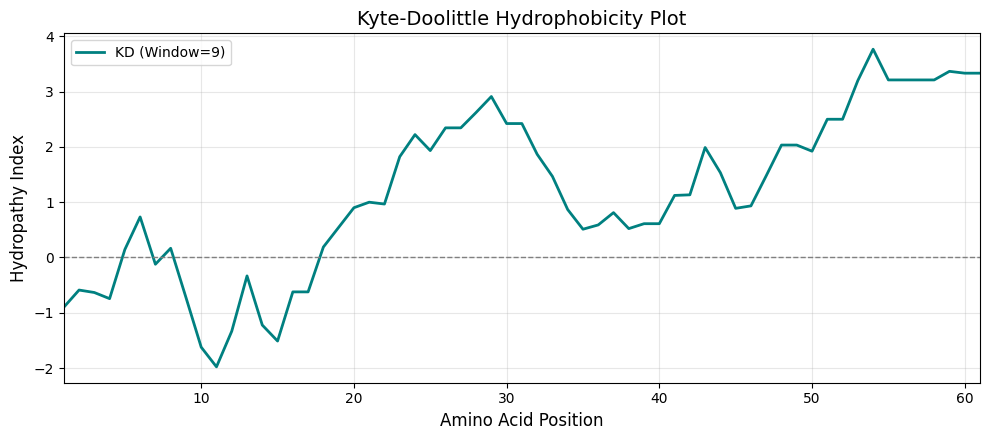

In [52]:
# Example sequence: Bacteriorhodopsin (a transmembrane protein)
# sequence = "EVQIVTKRIAEWEKKMINSIWLTTFVVFMFLAMPVSSQGILTSVLTVRYVVVVFIVALSVV" \
#           "AGFLAEGIWSSYWPFYWILILICALLGVIGATVQLTTGYGLYVLWAAAGVIMGIGVLG"

initial_peptide_report()

## **2. FASTA -> RDKit**
- Extracting SMILES from sequence or residues
- Comparing manual MW calculation against RDKit computation
- Draw the peptide

### Sequence to "Mol" Object (RDKit)

In [22]:
def seq_to_mol(seq):
  """
  Build an RDKit molecule (peptide) directly from a 1D, letter-based peptide sequence.
  RDKit assembles the residues and forms peptide bonds automatically.
  Args
    - seq: the 1D, letter-based peptide sequence
  Returns
    - mol
  """
  mol = Chem.MolFromSequence(seq)
  if mol is None:
    print("RDKit could not parse this sequence.")
  return mol

mol = seq_to_mol("EVQIVTKR")
print(type(mol))
print(mol)

<class 'rdkit.Chem.rdchem.Mol'>


### Extracting SMILES from the sequence

In [23]:
def get_smiles_from_seq(seq):
  mol = seq_to_mol(seq)
  smiles = Chem.MolToSmiles(mol)
  return smiles

get_smiles_from_seq("EVQIVTKR")

'CC[C@H](C)[C@H](NC(=O)[C@H](CCC(N)=O)NC(=O)[C@@H](NC(=O)[C@@H](N)CCC(=O)O)C(C)C)C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCNC(=N)N)C(=O)O)[C@@H](C)O)C(C)C'

### Comparing MW with the RDKit result

In [24]:
def compare_mw_rdkit(seq):
  """
  Cross-check manual MW calculation against RDKit's own computation.
  """
  mol = seq_to_mol(seq)
  rdkit_mw = Descriptors.MolWt(mol)
  manual_mw = get_mw(seq)
  print(f"RDKit MW  : {rdkit_mw:.2f} Da")
  print(f"Manual MW : {manual_mw:.2f} Da")
  print(f"Difference: {abs(rdkit_mw - manual_mw):.2f} Da")
  return rdkit_mw

### Draw peptide

In [25]:
def draw_peptide(seq):
  mol = seq_to_mol(seq)
  return Draw.MolToImage(mol, size=(700, 350))

### Example

Length: 5 residues
Raw Molecular Weight: 675.69 Da
True Molecular Weight: 603.61 Da (after 4 peptide bonds)

RDKit MW  : 603.63 Da
Manual MW : 603.61 Da
Difference: 0.02 Da

Molecule Draw:


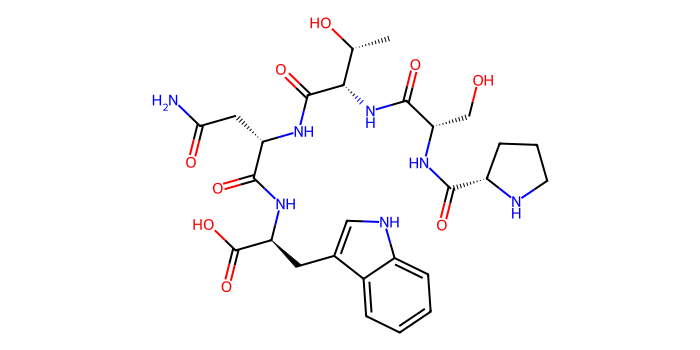

In [26]:
seq = "PSTNW"
get_smiles_from_seq(seq)
compare_mw_rdkit(seq)
print("\nMolecule Draw:")
draw_peptide(seq)

## **3. PDB residue analisys**

### Ubiquitin example of protein

In [27]:
!wget -q https://files.rcsb.org/download/1UBQ.pdb -O protein.pdb

In [28]:
three_to_one = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLU':'E','GLN':'Q',
    'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
    'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'
}

#### Get Sequence

In [29]:
def get_seq_from_pdb(pdb_path):
  """
  Parse a PDB file and extract the one-letter amino acid sequence
  of the protein chain, ignoring waters/ligands/hetero atoms.
  """
  u = mda.Universe(pdb_path)
  protein = u.select_atoms("protein")
  seq = "".join(three_to_one.get(res.resname, "X") for res in protein.residues)
  return seq, u
protein = get_seq_from_pdb("protein.pdb")
protein

('MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG',
 <Universe with 660 atoms>)

In [30]:
seq, u = get_seq_from_pdb("protein.pdb")
print(f"Sequence extracted from structure ({len(seq)} residues):\n{seq}")

get_mw(seq)
get_pI(seq)
most_commom_aa(seq)

Sequence extracted from structure (76 residues):
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
Length: 76 residues
Raw Molecular Weight: 9915.67 Da
True Molecular Weight: 8564.17 Da (after 75 peptide bonds)

Isoeletric Point (pI): 6.56
Most common: L (9x)


{'L': 9,
 'I': 7,
 'K': 7,
 'T': 7,
 'Q': 6,
 'G': 6,
 'E': 6,
 'D': 5,
 'V': 4,
 'R': 4,
 'P': 3,
 'S': 3,
 'F': 2,
 'N': 2,
 'A': 2,
 'M': 1,
 'Y': 1,
 'H': 1}

In [31]:
from MDAnalysis.analysis import distances
import matplotlib.pyplot as plt

#### Get Contact map

In [32]:
def get_contact_map(universe, cutoff=8.0):
  """
  Compute the CA-CA distance matrix and plot it as a contact map.
  cutoff (Å): distance threshold below which residues are considered "in contact"
  """
  ca_atoms = universe.select_atoms("protein and name CA")
  dist_matrix = distances.distance_array(ca_atoms.positions, ca_atoms.positions)

  contact_matrix = dist_matrix < cutoff

  fig, axes = plt.subplots(1, 2, figsize=(11, 5))

  im0 = axes[0].imshow(dist_matrix, cmap="viridis_r")
  axes[0].set_title("CA-CA Distance Map (Å)")
  axes[0].set_xlabel("Residue index")
  axes[0].set_ylabel("Residue index")
  fig.colorbar(im0, ax=axes[0], fraction=0.046)

  axes[1].imshow(contact_matrix, cmap="Greys")
  axes[1].set_title(f"Contact Map (cutoff = {cutoff} Å)")
  axes[1].set_xlabel("Residue index")
  axes[1].set_ylabel("Residue index")

  plt.tight_layout()
  plt.show()

  return dist_matrix, contact_matrix

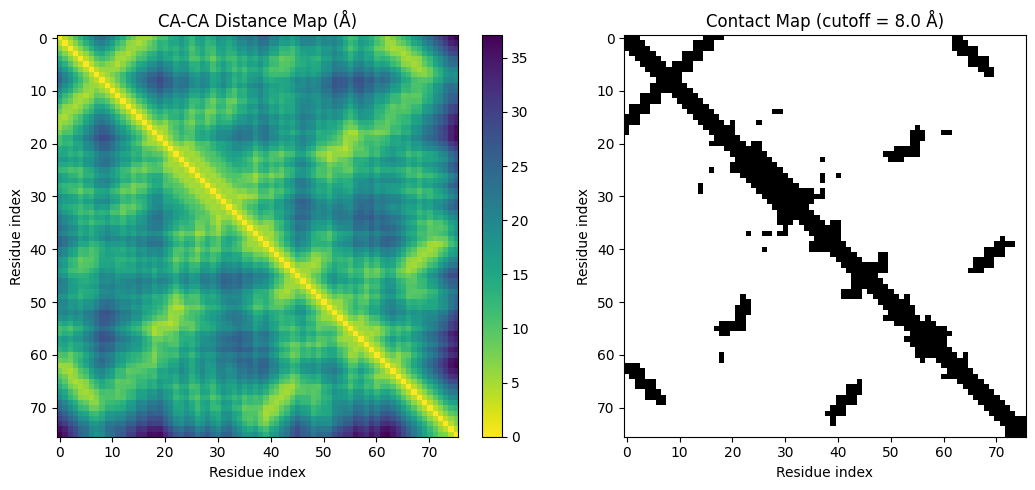

In [33]:
dist_matrix, contact_matrix = get_contact_map(u, cutoff=8.0)

## **4. CADD-flavored Molecule property calculator**

### Drugs SMILES

In [34]:
smiles_drugs = {
    "aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "caffeine": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "paracetamol": "CC(=O)NC1=CC=C(C=C1)O"
}

### Lipinski Rules

Lipinski's Rule of Five flags likely poor oral bioavailability if a molecule violates more than one of these four thresholds:



* MW ≤ 500
* LogP ≤ 5
* H-bond donors ≤ 5
* H-bond acceptors ≤ 10







In [35]:
def get_properties(drug_smiles):
  """
  Calculate the properties and Return a Dict
  Args:
    drug_smiles (str):
  Returns:
    Dict
  """
  drug_mol = Chem.MolFromSmiles(drug_smiles)
  properties = {}

  properties["SMILES"] = drug_smiles

  mw_drug = Descriptors.MolWt(drug_mol)
  properties["Molecular weight"] = mw_drug

  logP = Descriptors.MolLogP(drug_mol)
  properties["logP"] = logP

  H_donors = NumHDonors(drug_mol)
  properties["H_donors"] = H_donors

  H_acceptors = NumHAcceptors(drug_mol)
  properties["H_acceptors"] = H_acceptors
  return properties

In [36]:
drug_properties = {}
for name, smiles_string in smiles_drugs.items():
  drug_properties[name] = get_properties(smiles_string)
  print(f"Properties of {name}:\n")
  print(f"- SMILES: {drug_properties[name]["SMILES"]}")
  print(f"- Molecular Weight: {drug_properties[name]["Molecular weight"]:.2f}")
  print(f"- LogP: {drug_properties[name]["logP"]:.2f}")
  print(f"- Hydrogen Bond Donors: {drug_properties[name]["H_donors"]}")
  print(f"- Hydrogen Bond Acceptors: {drug_properties[name]["H_acceptors"]}\n")
  print("="*30)

Properties of aspirin:

- SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
- Molecular Weight: 180.16
- LogP: 1.31
- Hydrogen Bond Donors: 1
- Hydrogen Bond Acceptors: 3

Properties of caffeine:

- SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
- Molecular Weight: 194.19
- LogP: -1.03
- Hydrogen Bond Donors: 0
- Hydrogen Bond Acceptors: 3

Properties of ibuprofen:

- SMILES: CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
- Molecular Weight: 206.28
- LogP: 3.07
- Hydrogen Bond Donors: 1
- Hydrogen Bond Acceptors: 1

Properties of paracetamol:

- SMILES: CC(=O)NC1=CC=C(C=C1)O
- Molecular Weight: 151.16
- LogP: 1.35
- Hydrogen Bond Donors: 2
- Hydrogen Bond Acceptors: 2



In [37]:
df_prop = pd.DataFrame(drug_properties).T # "T" for transposing the values in the Data Frame
# Reset the axis and rename the first collum
df_prop = df_prop.rename_axis('Drug name').reset_index()
df_prop

,Drug name,SMILES,Molecular weight,logP,H_donors,H_acceptors
0,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,180.159,1.3101,1,3
1,caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3
2,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,206.285,3.0732,1,1
3,paracetamol,CC(=O)NC1=CC=C(C=C1)O,151.165,1.3506,2,2


#### Checking the Lipinski Rules for each molecule

##### Lipinski's check function

In [38]:
def lipinski_check(drug_properties):
  """
  Takes the dict for one molecule and returns how many of the four rules it violates (an integer 0–4).
  The Lipinski conditions are:
  - MW ≤ 500
  - LogP ≤ 5
  - H-bond donors ≤ 5
  - H-bond acceptors ≤ 10
  Args:
    drug_properties (dict): dict containing the properties of a molecule, name as key and another dict as a value
  """
  lipinski_count = 4
  if drug_properties['Molecular weight'] > 500: lipinski_count -= 1
  if drug_properties['logP'] > 5: lipinski_count -= 1
  if drug_properties['H_donors'] > 5: lipinski_count -= 1
  if drug_properties['H_acceptors'] > 10: lipinski_count -= 1
  return lipinski_count

##### Caffeine Example

In [39]:
caffeine_prop = get_properties(smiles_drugs['caffeine'])
caffeine_prop

{'SMILES': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
 'Molecular weight': 194.194,
 'logP': -1.0293,
 'H_donors': 0,
 'H_acceptors': 3}

In [40]:
caff_lipinski_count = lipinski_check(caffeine_prop)
caff_lipinski_count

4

#### Iterating to each Drug

In [41]:
drug_properties

{'aspirin': {'SMILES': 'CC(=O)OC1=CC=CC=C1C(=O)O',
  'Molecular weight': 180.15899999999996,
  'logP': 1.3101,
  'H_donors': 1,
  'H_acceptors': 3},
 'caffeine': {'SMILES': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
  'Molecular weight': 194.194,
  'logP': -1.0293,
  'H_donors': 0,
  'H_acceptors': 3},
 'ibuprofen': {'SMILES': 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
  'Molecular weight': 206.28499999999997,
  'logP': 3.073200000000001,
  'H_donors': 1,
  'H_acceptors': 1},
 'paracetamol': {'SMILES': 'CC(=O)NC1=CC=C(C=C1)O',
  'Molecular weight': 151.165,
  'logP': 1.3505999999999998,
  'H_donors': 2,
  'H_acceptors': 2}}

In [42]:
lipinkski_count_dict = {}
print("Check the Lipinski's Rule of Five for each Molecule:\n")
for name, properties in drug_properties.items():
  lipinkski_count = lipinski_check(properties)
  lipinkski_count_dict[name] = lipinkski_count
  print(f"- {name} complies with {lipinkski_count} rules of Lipinski's Rule of Five\n")

print(lipinkski_count_dict)

Check the Lipinski's Rule of Five for each Molecule:

- aspirin complies with 4 rules of Lipinski's Rule of Five

- caffeine complies with 4 rules of Lipinski's Rule of Five

- ibuprofen complies with 4 rules of Lipinski's Rule of Five

- paracetamol complies with 4 rules of Lipinski's Rule of Five

{'aspirin': 4, 'caffeine': 4, 'ibuprofen': 4, 'paracetamol': 4}


#### Adding the Number of Lipinki's Rules followed for each drug in the DataFrame

In [43]:
df_prop['Lipinski_Count'] = df_prop['Drug name'].map(lipinkski_count_dict)
df_prop

,Drug name,SMILES,Molecular weight,logP,H_donors,H_acceptors,Lipinski_Count
0,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,180.159,1.3101,1,3,4
1,caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3,4
2,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,206.285,3.0732,1,1,4
3,paracetamol,CC(=O)NC1=CC=C(C=C1)O,151.165,1.3506,2,2,4


In [44]:
df_prop['Passes_Lipinski'] = df_prop['Lipinski_Count'] >= 3

In [45]:
df_prop

,Drug name,SMILES,Molecular weight,logP,H_donors,H_acceptors,Lipinski_Count,Passes_Lipinski
0,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,180.159,1.3101,1,3,4,True
1,caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3,4,True
2,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,206.285,3.0732,1,1,4,True
3,paracetamol,CC(=O)NC1=CC=C(C=C1)O,151.165,1.3506,2,2,4,True


In [46]:
smiles_drugs["thymopentin"] = get_smiles_from_seq("RKDVY")
smiles_drugs

{'aspirin': 'CC(=O)OC1=CC=CC=C1C(=O)O',
 'caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
 'ibuprofen': 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O',
 'paracetamol': 'CC(=O)NC1=CC=C(C=C1)O',
 'thymopentin': 'CC(C)[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CCCCN)NC(=O)[C@@H](N)CCCNC(=N)N)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)O'}

### Function to add a new molecule

In [47]:
def add_molecule_to_dataframe(molecule_name, structure, is_peptide=False):
  """
  Adds a new molecule to the global smiles_drugs dictionary and updates the df_prop DataFrame.

  Args:
    molecule_name (str): The name of the molecule.
    structure (str): The SMILES string or the peptide sequence of the molecule.
    is_peptide (bool, optional): Set to True if the structure is a peptide sequence.
                                 Defaults to False (assumes SMILES).

  Returns:
    pd.DataFrame: The updated df_prop DataFrame.
  """
  global smiles_drugs, df_prop # Declare global to modify them directly

  # Determine SMILES representation
  if is_peptide:
    smiles_representation = get_smiles_from_seq(structure)
  else:
    smiles_representation = structure

  # Add the new drug to smiles_drugs dictionary
  smiles_drugs[molecule_name] = smiles_representation

  # Calculate properties for the new drug
  new_drug_properties = get_properties(smiles_representation)

  # Calculate Lipinski count for the new drug
  new_lipinski_count = lipinski_check(new_drug_properties)

  # Create a new DataFrame row for the new drug
  new_row_data = {
      'Drug name': molecule_name,
      'SMILES': new_drug_properties['SMILES'],
      'Molecular weight': new_drug_properties['Molecular weight'],
      'logP': new_drug_properties['logP'],
      'H_donors': new_drug_properties['H_donors'],
      'H_acceptors': new_drug_properties['H_acceptors'],
      'Lipinski_Count': new_lipinski_count
  }

  # Convert the dictionary to a DataFrame row
  new_df_row = pd.DataFrame([new_row_data])

  # Append this new row to df_prop
  df_prop = pd.concat([df_prop, new_df_row], ignore_index=True)

  # Recalculate 'Passes_Lipinski' for the entire df_prop to include the new entry
  df_prop['Passes_Lipinski'] = df_prop['Lipinski_Count'] >= 3

  print(f"'{molecule_name}' added to smiles_drugs and df_prop.")
  return df_prop

#### Example Usage: Adding a new small molecule (SMILES)

In [48]:
df_prop = add_molecule_to_dataframe("morphine", "CN1CCC23C4=C5C=CC(O)=C4OC2C(O)C=CC3C1C5")
df_prop

'morphine' added to smiles_drugs and df_prop.


,Drug name,SMILES,Molecular weight,logP,H_donors,H_acceptors,Lipinski_Count,Passes_Lipinski
0,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,180.159,1.3101,1,3,4,True
1,caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3,4,True
2,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,206.285,3.0732,1,1,4,True
3,paracetamol,CC(=O)NC1=CC=C(C=C1)O,151.165,1.3506,2,2,4,True
4,morphine,CN1CCC23C4=C5C=CC(O)=C4OC2C(O)C=CC3C1C5,285.343,1.1981,2,4,4,True


#### Example Usage: Adding a new peptide

In [49]:
df_prop = add_molecule_to_dataframe("melittin", "GIGAVLKVLTTGLPALISWIKRKRQQGGR", is_peptide=True)
display(df_prop)

'melittin' added to smiles_drugs and df_prop.


,Drug name,SMILES,Molecular weight,logP,H_donors,H_acceptors,Lipinski_Count,Passes_Lipinski
0,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,180.159,1.3101,1,3,4,True
1,caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3,4,True
2,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,206.285,3.0732,1,1,4,True
3,paracetamol,CC(=O)NC1=CC=C(C=C1)O,151.165,1.3506,2,2,4,True
4,morphine,CN1CCC23C4=C5C=CC(O)=C4OC2C(O)C=CC3C1C5,285.343,1.1981,2,4,4,True
5,melittin,CC[C@H](C)[C@H](NC(=O)CN)C(=O)NCC(=O)N[C@@H](C...,3117.792,-11.50389,47,41,1,False


# Save table

In [50]:
df_prop.to_csv('drug_properties.csv', index=False)